# Báo Cáo Chuyên Sâu: Chuỗi Phản Ứng Hủy Diệt (The Chain of Destruction)

Báo cáo này giải mã nguyên nhân gốc rễ dẫn đến sự sụt giảm biên lợi nhuận nghiêm trọng của công ty, thông qua 4 lăng kính phân tích cốt lõi của bài toán phân tích kinh doanh (Datathon Rubric). Phân tích không dừng lại ở mức độ khách hàng đơn lẻ, mà kết nối dữ liệu từ 3 hệ thống: **Vận hành (Inventory)**, **Định giá (Pricing)**, và **Khuyến mãi (Promotions)**.

---

## Phần 1. Descriptive Analytics: Chuyện gì đã xảy ra? (Sự bốc hơi lợi nhuận)

Dựa theo tiêu chí "Thống kê tổng hợp chính xác", nhóm tiến hành phân rã cấu trúc P&L (Profit & Loss) từ Báo cáo Doanh thu gộp (Gross Revenue) đến Dòng tiền thực thu (`Net Revenue = Gross Revenue - Discount`).

> **Thống kê Bất thường:** Hệ thống ghi nhận **13.12 Tỷ VNĐ** Doanh thu gộp (chỉ tính các đơn hàng giao thành công - Delivered), nhưng Lợi nhuận ròng (Net Profit) thu về cực kỳ mỏng, chỉ vỏn vẹn **1.21 Tỷ VNĐ** (do phải gánh khoản COGS quá lớn lên tới 11.30 Tỷ VNĐ). Đáng chú ý nhất, công ty đã tự tay "đốt" tới **600 Triệu VNĐ** vào các chương trình Khuyến mãi. Con số 600 Triệu VNĐ tương đương với **50% tổng lợi nhuận ròng** của toàn công ty! Nếu khoản chiết khấu khổng lồ này bị sử dụng lãng phí (bị trục lợi hoặc dùng cho sai tập khách hàng), nó sẽ là nhát dao chí mạng đâm thẳng vào "túi tiền" cuối cùng của doanh nghiệp. Sự "bào mòn" lợi nhuận này bắt nguồn từ đâu?

**Biểu đồ chứng minh (P&L Waterfall Chart):**


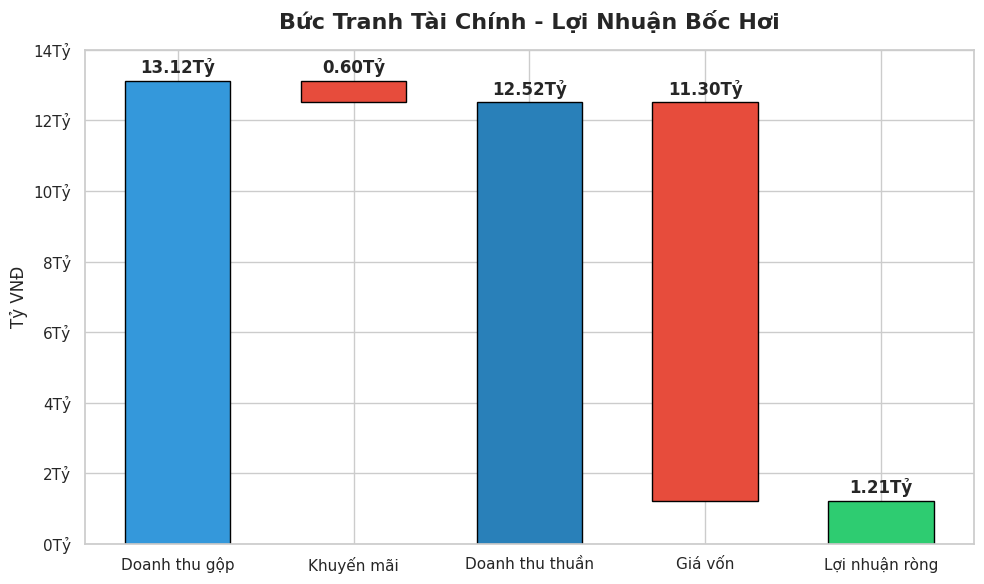

In [2]:
# CODE VẼ BIỂU ĐỒ WATERFALL (P&L) 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- LOAD DATA ---
root_path = '/kaggle/input/datasets/khanhduynguyenhuu/datathon/'
items = pd.read_csv(root_path + "order_items.csv", low_memory=False)
prods = pd.read_csv(root_path + 'products.csv')
orders = pd.read_csv(root_path + 'orders.csv')
items['quantity'] = pd.to_numeric(items['quantity'], errors='coerce')
items['unit_price'] = pd.to_numeric(items['unit_price'], errors='coerce')
items['discount_amount'] = pd.to_numeric(items['discount_amount'], errors='coerce')

# --- LỌC VÀ TÍNH TOÁN (Chỉ lấy đơn Delivered) ---
df_valid = items.merge(orders[['order_id', 'order_status']], on='order_id', how='left')
df_valid = df_valid[df_valid['order_status'] == 'delivered']
items_merged = df_valid.merge(prods[['product_id', 'cogs']], on='product_id', how='left')

gross_rev = (items_merged['unit_price'] * items_merged['quantity']).sum()
discount = items_merged['discount_amount'].sum()
cogs = (items_merged['cogs'] * items_merged['quantity']).sum()

# --- VẼ BIỂU ĐỒ ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

steps = ['Doanh thu gộp', 'Khuyến mãi', 'Doanh thu thuần', 'Giá vốn', 'Lợi nhuận ròng']
values = [gross_rev, -discount, 0, -cogs, 0]

running_total = 0
bottoms, heights, colors = [], [], []

for i, val in enumerate(values):
    if i == 0:
        bottoms.append(0); heights.append(val); colors.append('#3498db')
        running_total += val
    elif i == 2: # Doanh thu thuần
        bottoms.append(0); heights.append(running_total); colors.append('#2980b9')
    elif i == 4: # Lợi nhuận ròng (Chuyển từ index 5 xuống index 4)
        bottoms.append(0); heights.append(running_total); colors.append('#2ecc71')
    else: # Khuyến mãi (i=1) và Giá vốn (i=3)
        bottoms.append(running_total + val); heights.append(-val); colors.append('#e74c3c')
        running_total += val

bars = plt.bar(steps, heights, bottom=bottoms, color=colors, width=0.6, edgecolor='black')
plt.title("Bức Tranh Tài Chính - Lợi Nhuận Bốc Hơi", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Tỷ VNĐ")
plt.yticks(plt.yticks()[0], [f'{x/1e9:.0f}Tỷ' for x in plt.yticks()[0]])

for i, bar in enumerate(bars):
    yval = bar.get_height() + bar.get_y()
    val_text = heights[i] if i not in [2, 4] else running_total if i == 4 else (gross_rev - discount)
    
    plt.text(bar.get_x() + bar.get_width()/2, 
             yval + 1e8 if val_text > 0 else yval - 4e8, 
             f'{abs(val_text)/1e9:.2f}Tỷ', 
             ha='center', 
             va='bottom' if val_text > 0 else 'top', 
             fontweight='bold')

plt.tight_layout()
plt.show()


> **Nghịch lý Giá bán (Pricing Paradox):** Để tìm ra nguồn gốc của sự bào mòn này, nhóm đã bóc tách từng dòng dữ liệu hóa đơn (`order_items.csv` kết hợp với `cogs`). Kết quả gây sốc: Có tới **106,058 giao dịch** (chiếm **18.58%** tổng số sản phẩm được giao thành công) được hệ thống tự động niêm yết với giá bán thấp hơn cả giá vốn nhập hàng (`Unit Price < COGS`). Gần 1/5 lượng hàng của công ty bị bán lỗ ngay từ lúc lên kệ, CHƯA TÍNH ĐẾN việc khách hàng áp thêm mã giảm giá!

**Biểu đồ chứng minh (The Pricing Paradox):**


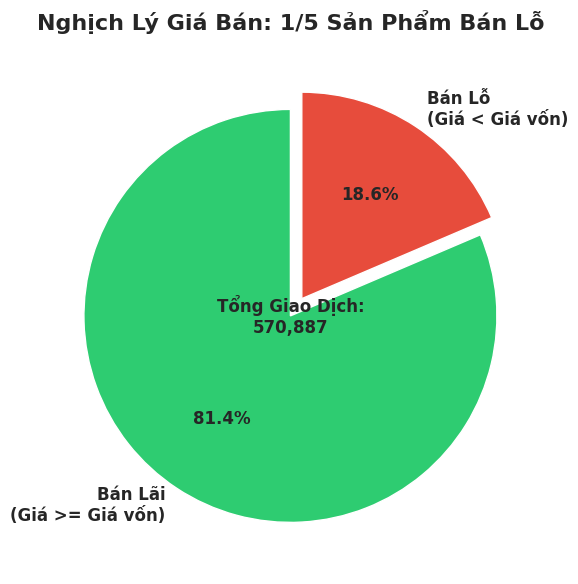

In [3]:
# CODE VẼ BIỂU ĐỒ NGHỊCH LÝ GIÁ BÁN

# Lọc các đơn hàng Delivered
df = items.merge(orders[['order_id', 'order_status']], on='order_id', how='left')
df = df[df['order_status'] == 'delivered']
df = df.merge(prods[['product_id', 'cogs']], on='product_id', how='left')
df['unit_price'] = pd.to_numeric(df['unit_price'], errors='coerce')

below_cogs = len(df[df['unit_price'] < df['cogs']])
above_cogs = len(df[df['unit_price'] >= df['cogs']])

# Vẽ Donut Chart
plt.figure(figsize=(8, 6))
labels = ['Bán Lãi\n(Giá >= Giá vốn)', 'Bán Lỗ\n(Giá < Giá vốn)']
sizes = [above_cogs, below_cogs]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=False, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title("Nghịch Lý Giá Bán: 1/5 Sản Phẩm Bán Lỗ", fontsize=16, fontweight='bold', pad=20)
plt.text(0, 0, f"Tổng Giao Dịch:\n{len(df):,}", ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Tại sao công ty lại liên tục hạ giá bán xuống dưới giá vốn một cách tự sát như vậy? Và quan trọng hơn, lỗ hổng định giá này đã tiếp tay thế nào cho việc "đốt" vô ích một phần lớn trong ngân sách 600 Triệu VNĐ tiền khuyến mãi? Câu trả lời nằm ở đằng sau cánh cửa Nhà kho.

---

## Phần 2. Diagnostic Analytics: Tại sao lại xảy ra? (Đi tìm Lỗ hổng Hệ thống)

Để tìm ra nguyên nhân, nhóm đặt ra các giả thuyết cốt lõi về Chuỗi cung ứng và Cấu trúc Định giá.

### 2.1. Xác định Bất thường: Khủng hoảng "Tồn Kho Ảo" (Phantom Inventory)
> **Phân tích:** Công ty bị lỗ do bán dưới giá vốn không phải vì chiến lược giá sai, cũng không phải do dư thừa nguồn cung, mà do **Dữ liệu hệ thống đếm sai hoàn toàn (Data Error)**. Hệ thống báo cáo kho đang ứ đọng, nhưng thực chất trên kệ trống rỗng. Bằng chứng là sự xuất hiện của 30,495 bản ghi dị thường: Sản phẩm bị Đứt hàng (`stockout_days > 0`) nhưng Tồn kho hệ thống lại cực kỳ cao (`overstock_flag = 1`).

**Biểu đồ chứng minh (Phantom Pie Chart):**

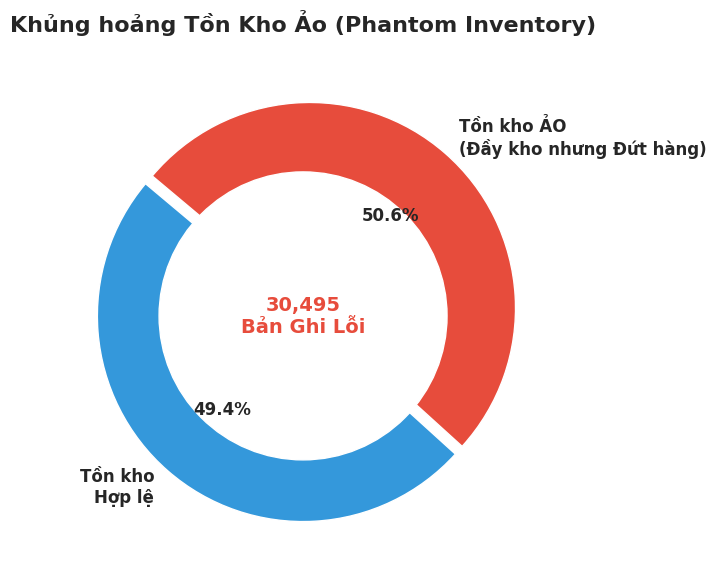

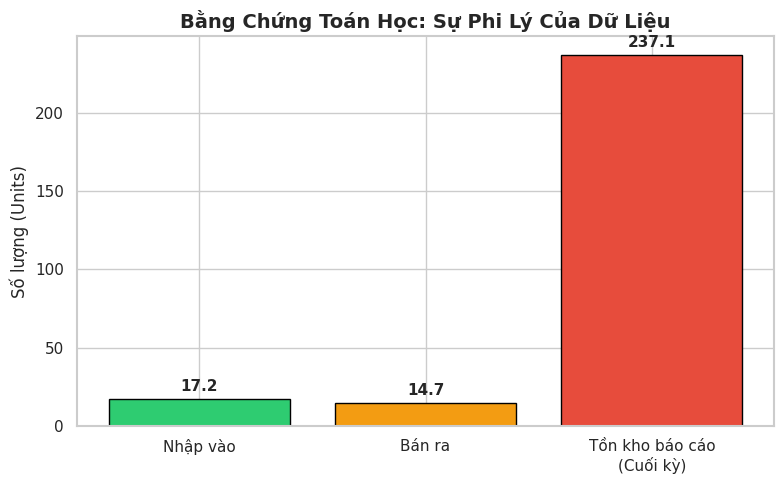

In [11]:
# CODE VẼ BIỂU ĐỒ PHẦN B.1

inv = pd.read_csv(root_path +'inventory.csv')

# 1. Vẽ Donut Chart thể hiện tỷ lệ Tồn kho Ảo
phantom_count = len(inv[(inv['overstock_flag'] == 1) & (inv['stockout_days'] > 0)])
normal_count = len(inv) - phantom_count

plt.figure(figsize=(8, 6))
labels = ['Tồn kho\nHợp lệ', 'Tồn kho ẢO\n(Đầy kho nhưng Đứt hàng)']
sizes = [normal_count, phantom_count]
colors = ['#3498db', '#e74c3c']
explode = (0, 0.05)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=False, startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold'})
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Khủng hoảng Tồn Kho Ảo (Phantom Inventory)", fontsize=16, fontweight='bold', pad=20)
plt.text(0, 0, f"30,495\nBản Ghi Lỗi", ha='center', va='center', fontsize=14, fontweight='bold', color='#e74c3c')
plt.tight_layout()
plt.show()

# 2. Vẽ Bar Chart chứng minh toán học
phantom_data = inv[(inv['overstock_flag'] == 1) & (inv['stockout_days'] > 0)]
avg_sold = phantom_data['units_sold'].mean()
avg_received = phantom_data['units_received'].mean()
avg_stock = phantom_data['stock_on_hand'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Nhập vào', 'Bán ra', 'Tồn kho báo cáo\n(Cuối kỳ)'], 
               [avg_received, avg_sold, avg_stock], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
plt.title("Bằng Chứng Toán Học: Sự Phi Lý Của Dữ Liệu", fontsize=14, fontweight='bold')
plt.ylabel("Số lượng (Units)")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f"{bar.get_height():.1f}", 
             ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

**Phân tích Bằng chứng Toán học:**
Sự phi lý tột độ của hệ thống thông qua phép toán sau (số liệu trung bình của 30,495 bản ghi lỗi):
1. **Bán ra trung bình:** 14.7 units/tháng.
2. **Nhập vào trung bình:** 17.2 units/tháng.
3. **Tồn kho hệ thống báo cáo (Cuối kỳ):** 237.1 units.
$\Rightarrow$ Tồn kho đầu tháng = Tồn cuối (237.1) - Nhập (17.2) + Bán (14.7) $\approx$ **234.6 units.**

**Lỗ hổng Logic chết người:** Nếu đầu tháng công ty thực sự có tới 234 cái áo trong kho, và cả tháng chỉ bán được vỏn vẹn 14 cái, thì **tại sao khách hàng lại bị báo Hết hàng (Stockout)?** 
Câu trả lời suy luận duy nhất: **Hơn 200 đơn vị tồn kho kia là ẢO.** Đó có thể là hàng đã mất cắp, đếm sai, hoặc hỏng hóc hoàn toàn nhưng hệ thống ERP vẫn đếm là "Stock on hand".
Hậu quả: Hệ thống bị ảo giác là kho đang ứ đọng quá mức, nên nó tự động kích hoạt thuật toán giảm giá để xả kho tống khứ những món hàng này đi.


### 2.2. Giả thuyết Nhân quả: Lỗ hổng Thanh lý (The Liquidation Loophole)
> **Phân tích:** Vì hệ thống ảo tưởng rằng đang bị "Tồn kho" khổng lồ ở phần 2.1, thuật toán định giá hoảng loạn kích hoạt chế độ **Xả kho tự động (`unit_price < COGS`)**. Tuy nhiên, do lỗi thiết kế, các mã giảm giá toàn cục (Promo Codes) **không bị vô hiệu hóa** (No-stacking Rule) cho hàng xả kho. Nhóm khách hàng sử dụng mã giảm giá (Seekers) đã lợi dụng điều này. Nếu đúng, tỉ lệ áp mã Promo trên nhóm Xả kho sẽ cao đột biến.

**Biểu đồ chứng minh (The Liquidation Loophole):**

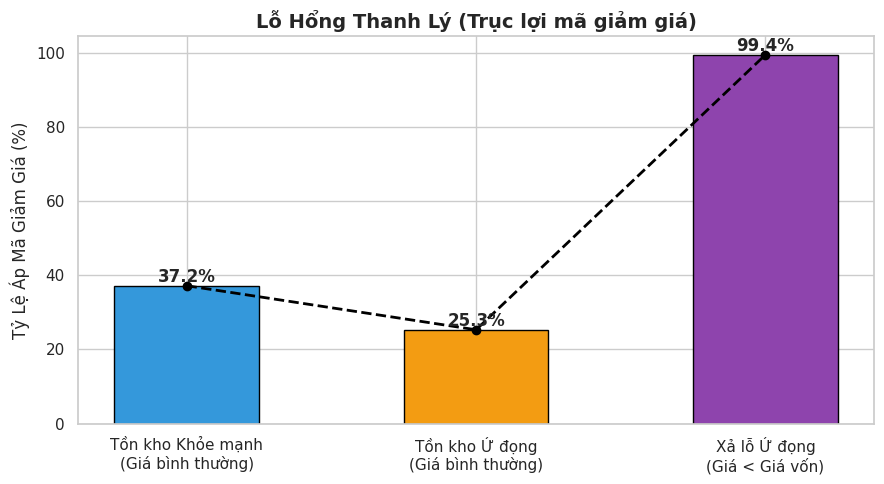

In [5]:
# CODE VẼ BIỂU ĐỒ PHẦN B.2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Lấy dữ liệu và phân tách Tháng/Năm để chống nhiễu thời gian
df_valid_b2 = items.merge(orders[['order_id', 'order_status', 'order_date']], on='order_id', how='left')
df_valid_b2 = df_valid_b2[df_valid_b2['order_status'] == 'delivered'].copy()
df_valid_b2['order_date'] = pd.to_datetime(df_valid_b2['order_date'])
df_valid_b2['year'] = df_valid_b2['order_date'].dt.year
df_valid_b2['month'] = df_valid_b2['order_date'].dt.month

# Ghép cờ Overstock chính xác theo từng tháng giao dịch
items_merged_b2 = df_valid_b2.merge(prods[['product_id', 'cogs']], on='product_id', how='left')
df_b2 = items_merged_b2.merge(inv[['product_id', 'year', 'month', 'overstock_flag']], on=['product_id', 'year', 'month'], how='left')
df_b2['is_below_cogs'] = df_b2['unit_price'] < df_b2['cogs']
df_b2['has_promo'] = pd.to_numeric(df_b2['discount_amount'], errors='coerce') > 0

conds = [
    (df_b2['overstock_flag'] == 0),
    (df_b2['overstock_flag'] == 1) & (~df_b2['is_below_cogs']),
    (df_b2['overstock_flag'] == 1) & (df_b2['is_below_cogs'])
]
choics = ['Tồn kho Khỏe mạnh\n(Giá bình thường)', 'Tồn kho Ứ đọng\n(Giá bình thường)', 'Xả lỗ Ứ đọng\n(Giá < Giá vốn)']
df_b2['Inventory_State'] = np.select(conds, choics, default='Other')
df_b2 = df_b2[df_b2['Inventory_State'] != 'Other']

promo_stats = df_b2.groupby('Inventory_State').agg(promo_usage_pct=('has_promo', lambda x: x.mean() * 100)).reindex(choics)

plt.figure(figsize=(9, 5))
bars = plt.bar(promo_stats.index, promo_stats['promo_usage_pct'], color=['#3498db', '#f39c12', '#8e44ad'], edgecolor='black', width=0.5)
plt.plot(promo_stats.index, promo_stats['promo_usage_pct'], color='black', marker='o', linestyle='--', linewidth=2)
plt.title("Lỗ Hổng Thanh Lý (Trục lợi mã giảm giá)", fontsize=14, fontweight='bold')
plt.ylabel("Tỷ Lệ Áp Mã Giảm Giá (%)")
for i, val in enumerate(promo_stats['promo_usage_pct']):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()

plt.show()

**Kết quả Phân tích:**
- **Tồn kho Khỏe mạnh (Giá bình thường):** Tỷ lệ dùng Promo tự nhiên là **37.2%**.
- **Tồn kho Ứ đọng (Giá bình thường):** Tỷ lệ dùng Promo **GIẢM CÒN 25.3%** (vì hàng kém hấp dẫn).
- **Xả lỗ Ứ đọng (Giá < Giá vốn):** Cột màu tím vọt lên **99.4%**! Tỷ lệ áp mã này đã trực tiếp bòn rút **215.5 Triệu VNĐ** tiền mặt. Tính rộng ra toàn bộ các mặt hàng bị bán dưới giá vốn, số tiền Khuyến mãi bị lãng phí lên tới **296.8 Triệu VNĐ** (chiếm MỘT NỬA tổng ngân sách Promo 600 triệu của toàn công ty). Một nửa quỹ Marketing đang được dùng để tặng không cho những hóa đơn xả lỗ!

### 2.3. So sánh Phân khúc: Ma trận Rủi ro (Sự Chôn Vốn Khổng Lồ)
> **Phân tích:** Biểu đồ bóc tách sự thật tàn khốc: Nhóm `Everyday` và `Activewear` đang ở **Góc Tử Thần**. Dù chỉ số Sell-through chỉ lệch 0.05 so với Balanced, nhưng về mặt tương đối, Balanced đang bán **nhanh hơn tới 45%**. Sự chậm chạp này cộng hưởng với việc nhập hàng vô tội vạ khiến trục Y (Thời gian tồn kho) của Activewear vọt lên tới 1,800 ngày (5 năm). Đáng chú ý, toàn hệ thống đang chìm trong "ảo giác" Tồn kho ảo (đã chứng minh ở 2.1) khiến Days of Supply trung bình đều bị đẩy lên mức phi lý. Dù vậy, nhóm `Balanced` vẫn là tia sáng nằm ở **Góc Tiềm Năng** vì tốc độ tiêu thụ (Trục X) vượt trội nhất. Rõ ràng công ty đang chôn vốn khổng lồ vào những nhóm hàng ế ẩm nhất.

**Biểu đồ chứng minh (Ma trận Rủi ro Segment):**

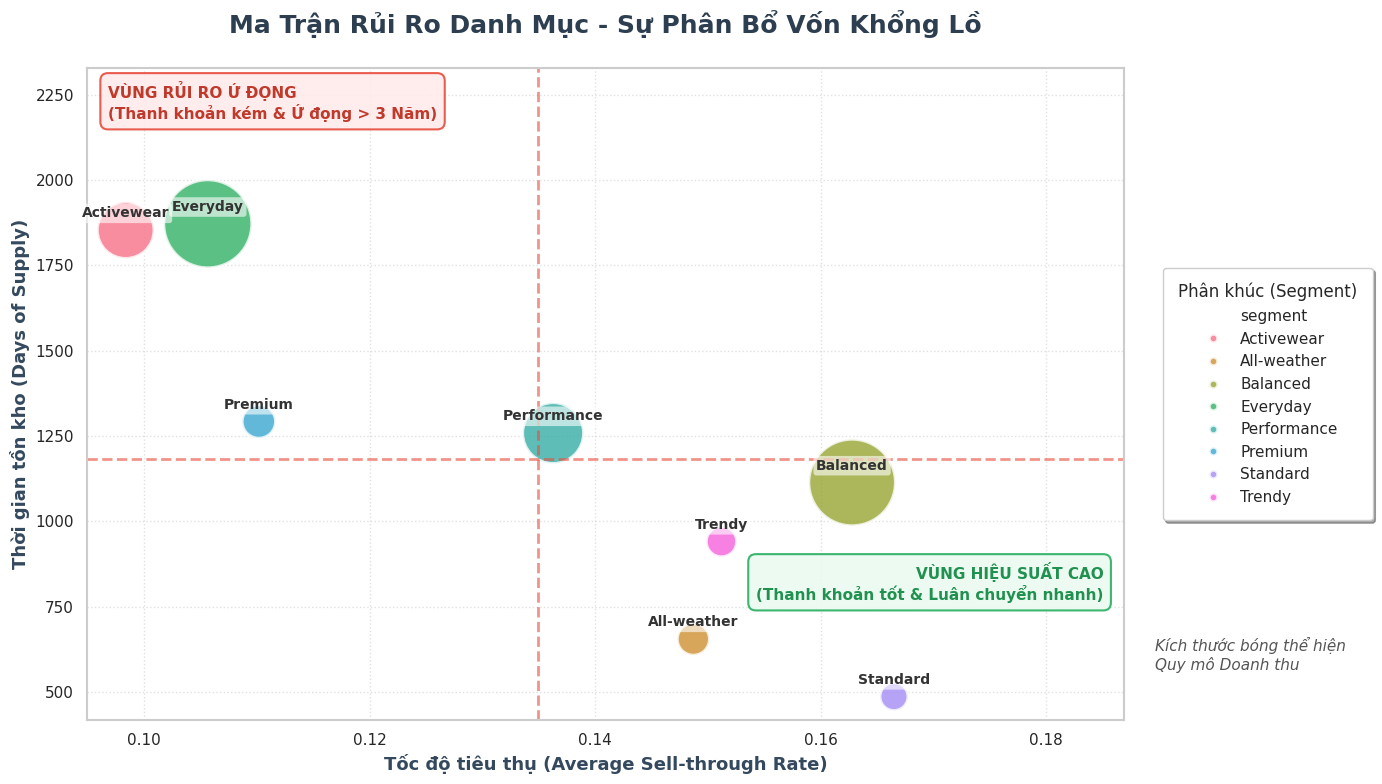

In [6]:
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#cccccc", "axes.linewidth": 1.5})
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']})
# Load data
df_inv = pd.read_csv(root_path + 'inventory.csv')
df_prods = pd.read_csv(root_path + 'products.csv')

# 1. Tính Gross Revenue theo Segment (Đổi ra Tỷ VNĐ)
df_inv_prod = df_inv.merge(df_prods[['product_id', 'price']], on='product_id', how='left')
df_inv_prod['gross_revenue'] = (df_inv_prod['units_sold'] * df_inv_prod['price']) / 1e9
rev_by_segment = df_inv_prod.groupby('segment')['gross_revenue'].sum().reset_index()

# 2. Tính Sell-through và Days of Supply trung bình theo Segment (2019-2022)
inv_recent = df_inv_prod[df_inv_prod['year'] >= 2019]
inv_stats_segment = inv_recent.groupby('segment').agg(
    avg_sell_through=('sell_through_rate', 'mean'),
    avg_dos=('days_of_supply', 'mean')
).reset_index()

# 3. Kết hợp dữ liệu
bubble_data = pd.merge(inv_stats_segment, rev_by_segment, on='segment', how='inner')

# Visualization
fig, ax = plt.subplots(figsize=(14, 8))

colors = sns.color_palette("husl", len(bubble_data))

# Tối ưu kích thước bóng
sns.scatterplot(
    data=bubble_data, x='avg_sell_through', y='avg_dos', 
    size='gross_revenue', hue='segment', sizes=(400, 4000), 
    alpha=0.8, palette=colors, edgecolor='white', linewidth=2, ax=ax
)

# Lấy giới hạn trục
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Mở rộng trần X và Y (20% Y, 10% X)
ax.set_ylim(y_min, y_max * 1.20)
ax.set_xlim(x_min, x_max * 1.10) 
y_range = (y_max * 1.20) - y_min

# Thêm nhãn cho từng bóng (Đặt phía TRÊN tâm)
for i, row in bubble_data.iterrows():
    ax.text(row['avg_sell_through'], row['avg_dos'] + (y_range * 0.015), row['segment'], 
             horizontalalignment='center', verticalalignment='bottom', 
             size=10, color='#333333', weight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

ax.set_title('Ma Trận Rủi Ro Danh Mục - Sự Phân Bổ Vốn Khổng Lồ', 
             fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
ax.set_xlabel('Tốc độ tiêu thụ (Average Sell-through Rate)', fontsize=13, fontweight='bold', color='#34495e')
ax.set_ylabel('Thời gian tồn kho (Days of Supply)', fontsize=13, fontweight='bold', color='#34495e')

# Đường trung bình chia góc phần tư
mean_x = bubble_data['avg_sell_through'].mean()
mean_y = bubble_data['avg_dos'].mean()

ax.axvline(mean_x, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=2)
ax.axhline(mean_y, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=2)

bbox_props_red = dict(boxstyle="round,pad=0.5", fc="#ffeaea", ec="#e74c3c", lw=1.5, alpha=0.9)
ax.text(0.02, 0.98, "VÙNG RỦI RO Ứ ĐỌNG\n(Thanh khoản kém & Ứ đọng > 3 Năm)", 
        transform=ax.transAxes, ha='left', va='top', 
        color='#c0392b', fontsize=11, fontweight='bold', bbox=bbox_props_red)

bbox_props_green = dict(boxstyle="round,pad=0.5", fc="#eafaf1", ec="#27ae60", lw=1.5, alpha=0.9)
# Vùng Hiệu Suất Cao: Kéo tọa độ Y từ 0.02 lên 0.18 (lơ lửng ngay trên bóng Standard)
ax.text(0.98, 0.18, "VÙNG HIỆU SUẤT CAO\n(Thanh khoản tốt & Luân chuyển nhanh)", 
        transform=ax.transAxes, ha='right', va='bottom', 
        color='#219150', fontsize=11, fontweight='bold', bbox=bbox_props_green)
# =========================================================================

handles, labels = ax.get_legend_handles_labels()
try:
    rev_idx = labels.index('gross_revenue')
    handles = handles[:rev_idx]
    labels = labels[:rev_idx]
except ValueError:
    pass

ax.legend(handles, labels, bbox_to_anchor=(1.03, 0.5), loc='center left', 
          frameon=True, shadow=True, borderpad=1, title="Phân khúc (Segment)", fontsize=11, title_fontsize=12)

ax.text(1.03, 0.1, "Kích thước bóng thể hiện\nQuy mô Doanh thu", 
        transform=ax.transAxes, ha='left', va='center', fontsize=11, style='italic', color='#555555')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

plt.show()




---

## Phần 3. Predictive Analytics: Dự Báo Sự Sụp Đổ

### 3.1. Ngoại Suy Xu Hướng (Trend Extrapolation): Rủi Ro Mất Kiểm Soát Tồn Kho
Bằng cách thiết lập "Điểm gãy cấu trúc" (Structural Break) từ năm 2016 (Đỉnh chu kỳ doanh thu), thuật toán Hồi quy Tuyến tính (Linear Regression) với độ tin cậy rất cao (R² = 0.98) đã ngoại suy một sự phân kỳ cấu trúc: Doanh thu có xu hướng suy giảm tuyến tính trong khi Thời gian tồn kho (Days of Supply) tăng với gia tốc khoảng +140 ngày/năm.

> **Giải mã Biến động 2022 (Sự phục hồi cục bộ):** Biểu đồ cho thấy năm 2022 doanh thu có dấu hiệu phục hồi. Tuy nhiên, phân tích sâu dữ liệu lịch sử chứng minh đây là hệ quả của việc áp dụng chính sách chiết khấu sâu (thanh lý trung bình 20% lượng hàng hóa mỗi năm) để kích cầu. Đáng chú ý, bất chấp nỗ lực thanh lý để bảo vệ doanh thu ngắn hạn, đường Tồn kho (màu đỏ) của năm 2022 vẫn tiếp tục xu hướng tăng, chạm mốc 1,638 ngày. Thuật toán dự báo đã điều chỉnh độ nhiễu của sự kiện này để nội suy đúng bản chất chu kỳ: Đến năm 2025, công ty sẽ cần tới **gần 6 năm (2,055 ngày)** mới luân chuyển hết lượng hàng tồn nếu không có các biện pháp tái cấu trúc chuỗi cung ứng.




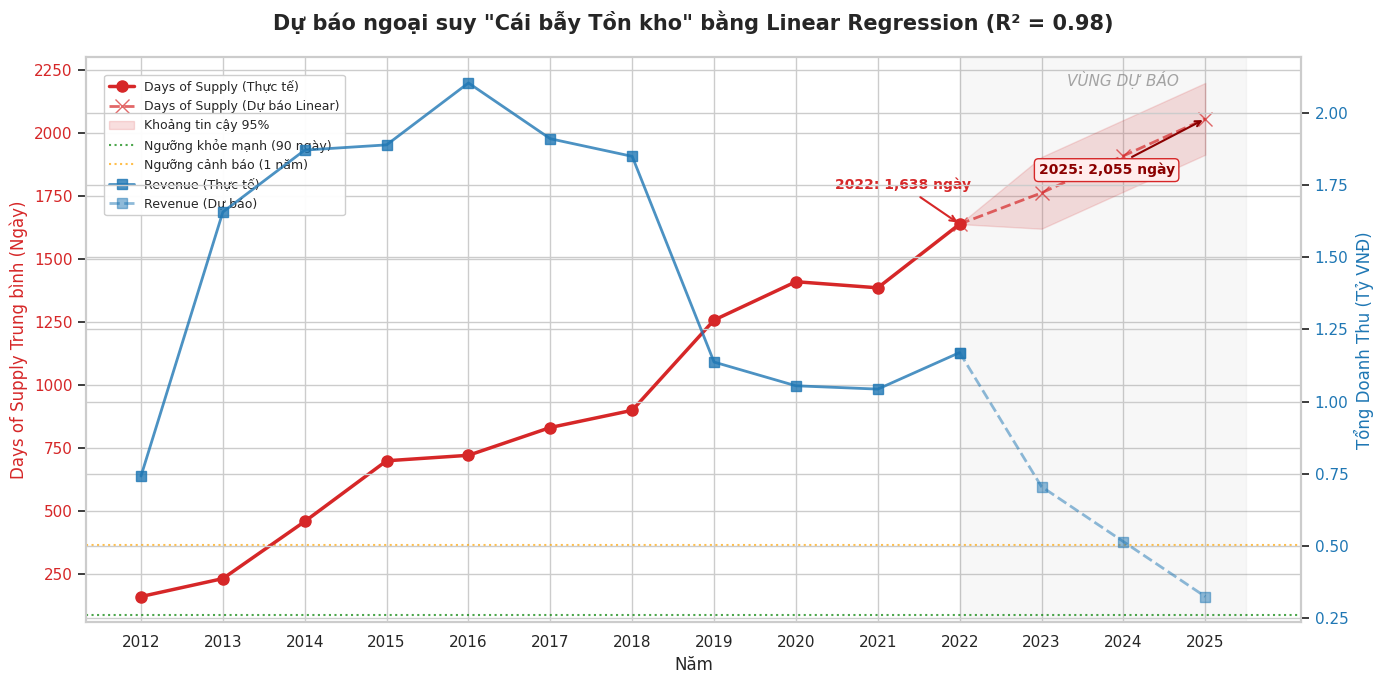

In [7]:

from sklearn.linear_model import LinearRegression

# Load data
df_inv = pd.read_csv(root_path +'inventory.csv')
df_sales = pd.read_csv(root_path +'sales.csv', parse_dates=['Date'])
df_sales['year'] = df_sales['Date'].dt.year

# 1. Dữ liệu thực tế
dos_yearly = df_inv.groupby('year')['days_of_supply'].mean().reset_index()
dos_yearly.columns = ['year', 'dos']

rev_yearly = df_sales.groupby('year')['Revenue'].sum().reset_index()
rev_yearly['Revenue'] = rev_yearly['Revenue'] / 1e9  # Tỷ VNĐ

# 2. Fit Linear Regression cho DOS
X = dos_yearly['year'].values.reshape(-1, 1)
y = dos_yearly['dos'].values
model_dos = LinearRegression().fit(X, y)
r2_dos = model_dos.score(X, y)

# 3. Fit Linear Regression cho Revenue (từ 2016)
rev_decline = rev_yearly[rev_yearly['year'] >= 2016].copy()
X_rev = rev_decline['year'].values.reshape(-1, 1)
y_rev = rev_decline['Revenue'].values
model_rev = LinearRegression().fit(X_rev, y_rev)
r2_rev = model_rev.score(X_rev, y_rev)

# 4. Ngoại suy 2023-2025
future_years = np.array([2023, 2024, 2025]).reshape(-1, 1)
dos_projected = model_dos.predict(future_years)
rev_projected = model_rev.predict(future_years)
dos_std = np.std(y - model_dos.predict(X))

# 5. Visualization
fig, ax1 = plt.subplots(figsize=(14, 7))

# Actual DOS
ax1.plot(dos_yearly['year'], dos_yearly['dos'], 'o-', color='#d62728', linewidth=2.5, markersize=8, label='Days of Supply (Thực tế)', zorder=5)

# Projected DOS
proj_years = [2022] + [2023, 2024, 2025]
proj_values = [dos_yearly[dos_yearly['year']==2022]['dos'].values[0]] + list(dos_projected)
ax1.plot(proj_years, proj_values, 'x--', color='#d62728', linewidth=2, markersize=10, alpha=0.7, label='Days of Supply (Dự báo Linear)')

# Confidence interval
ci_upper = [proj_values[0]] + list(dos_projected + 1.96 * dos_std)
ci_lower = [proj_values[0]] + list(dos_projected - 1.96 * dos_std)
ax1.fill_between(proj_years, ci_lower, ci_upper, alpha=0.15, color='#d62728', label='Khoảng tin cậy 95%')

# Reference Lines
ax1.axhline(90, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label='Ngưỡng khỏe mạnh (90 ngày)')
ax1.axhline(365, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Ngưỡng cảnh báo (1 năm)')

# Revenue trục phụ
ax2 = ax1.twinx()
ax2.plot(rev_yearly['year'], rev_yearly['Revenue'], 's-', color='#1f77b4', linewidth=2, markersize=7, label='Revenue (Thực tế)', alpha=0.8)
rev_proj_years = [2022] + [2023, 2024, 2025]
rev_proj_vals = [rev_yearly[rev_yearly['year']==2022]['Revenue'].values[0]] + list(rev_projected)
ax2.plot(rev_proj_years, rev_proj_vals, 's--', color='#1f77b4', linewidth=2, markersize=7, alpha=0.5, label='Revenue (Dự báo)')
ax2.set_ylabel('Tổng Doanh Thu (Tỷ VNĐ)', color='#1f77b4', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#1f77b4')

# Annotations
val_2022 = dos_yearly[dos_yearly['year']==2022]['dos'].values[0]
ax1.annotate(f"2022: {val_2022:,.0f} ngày", xy=(2022, val_2022), xytext=(-90, 25), textcoords='offset points', fontsize=10, fontweight='bold', color='#d62728', arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))
ax1.annotate(f"2025: {dos_projected[-1]:,.0f} ngày", xy=(2025, dos_projected[-1]), xytext=(-120, -40), textcoords='offset points', fontsize=10, fontweight='bold', color='#8B0000', arrowprops=dict(arrowstyle='->', color='#8B0000', lw=1.5), bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFECEC', edgecolor='#d62728'))

ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Days of Supply Trung bình (Ngày)', color='#d62728', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#d62728')
ax1.set_xticks(list(range(2012, 2026)))
ax1.axvspan(2022, 2025.5, alpha=0.06, color='gray')
ax1.text(2024, ax1.get_ylim()[1]*0.95, 'VÙNG DỰ BÁO', ha='center', fontsize=11, fontstyle='italic', color='gray', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.01, 0.98), frameon=True, facecolor='white', framealpha=0.95, fontsize=9)

plt.title(f'Dự báo ngoại suy "Cái bẫy Tồn kho" bằng Linear Regression (R² = {r2_dos:.2f})', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()



### 3.2. Phân Tích Tính Mùa Vụ (Seasonality Analysis): Đứt gãy Chuỗi cung ứng
Bản đồ phân tích chỉ ra sự phản tác dụng của hệ thống dự báo: Hệ thống liên tục nhập dư thừa hàng vào những tháng thấp điểm, nhưng lại để kho trống rỗng (Stockout) ngay đúng giai đoạn Doanh thu đạt đỉnh (Peak Season: Tháng 4 - Tháng 6). Khách hàng đang bỏ đi vì thiếu hàng vào lúc họ cần nhất.




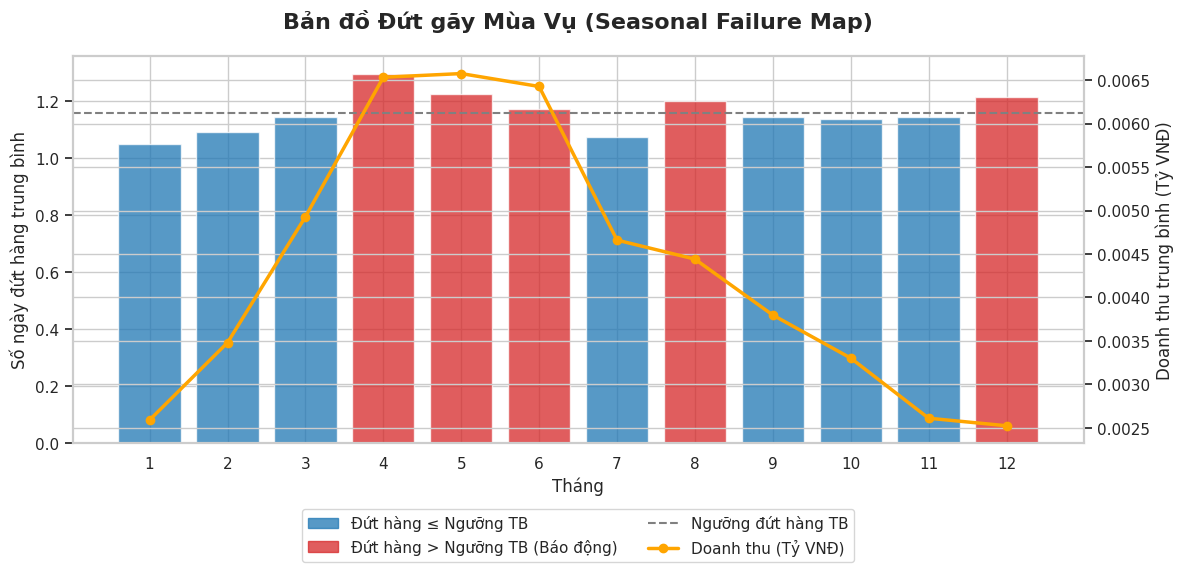

In [8]:
# CODE VẼ BIỂU ĐỒ PHẦN D.4 (SEASONAL FAILURE MAP)
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

inv = pd.read_csv(root_path +'inventory.csv')
sales = pd.read_csv(root_path +'sales.csv', parse_dates=['Date'])

# 1. Tính toán số ngày đứt hàng trung bình theo 12 tháng
monthly_stockout = inv.groupby('month')['stockout_days'].mean().reset_index()
avg_stockout_all = monthly_stockout['stockout_days'].mean()

# 2. Tính Doanh thu theo tháng
sales['month'] = sales['Date'].dt.month
monthly_revenue = sales.groupby('month')['Revenue'].mean().reset_index()

# 3. Vẽ Dual-axis Bar Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

colors = ['#d62728' if val > avg_stockout_all else '#1f77b4' for val in monthly_stockout['stockout_days']]
ax1.bar(monthly_stockout['month'], monthly_stockout['stockout_days'], color=colors, alpha=0.75)
ax1.axhline(avg_stockout_all, color='gray', linestyle='--', linewidth=1.5)

ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Số ngày đứt hàng trung bình', fontsize=12)
ax1.set_xticks(range(1, 13))

# Trục phụ: Line Chart (Doanh thu trung bình)
ax2 = ax1.twinx()
ax2.plot(monthly_revenue['month'], monthly_revenue['Revenue'] / 1e9, color='orange', marker='o', linewidth=2.5)
ax2.set_ylabel('Doanh thu trung bình (Tỷ VNĐ)', fontsize=12)

# Custom Legend
blue_patch = mpatches.Patch(color='#1f77b4', alpha=0.75, label='Đứt hàng ≤ Ngưỡng TB')
red_patch = mpatches.Patch(color='#d62728', alpha=0.75, label='Đứt hàng > Ngưỡng TB (Báo động)')
avg_line = mlines.Line2D([], [], color='gray', linestyle='--', linewidth=1.5, label='Ngưỡng đứt hàng TB')
rev_line = mlines.Line2D([], [], color='orange', marker='o', linewidth=2.5, label='Doanh thu (Tỷ VNĐ)')

ax1.legend(handles=[blue_patch, red_patch, avg_line, rev_line], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)
plt.title('Bản đồ Đứt gãy Mùa Vụ (Seasonal Failure Map)', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()

plt.show()



### 3.3. Dự báo khách hàng: Tốn tiền thu hút sai khách
> **Vòng lặp gây lỗ:**
> Lỗi Tồn kho Ảo $\rightarrow$ Hệ thống Bán dưới giá vốn $\rightarrow$ Khách hàng lợi dụng Promo. 
> Việc liên tục vận hành theo cấu trúc này đang tạo ra vấn đề lớn hơn. Nhóm dự báo công ty đang tự hủy hoại **Giá trị Vòng đời Khách hàng (Customer Lifetime Value - LTV)** dài hạn.

Để chứng minh, nhóm tiến hành chia 85,115 khách hàng thành 2 nhóm dựa trên **Đơn hàng đầu tiên (Acquisition Order)**:
1. **Khách Tự Nhiên:** Không dùng Promo ở đơn đầu. Mua trung bình 6.9 đơn, mang lại LTV = 168,318 VNĐ/người.
2. **Khách Chuyên Săn Sale:** Bị "neo giá" bởi sự rẻ rúng. Mua ít hơn (4.3 đơn), LTV bèo bọt = 100,199 VNĐ/người.

Cái bẫy 600 Triệu: Công ty đang "đốt" tiền chiết khấu để kéo về một tệp khách hàng không mang lại lợi nhuận trong tương lai!




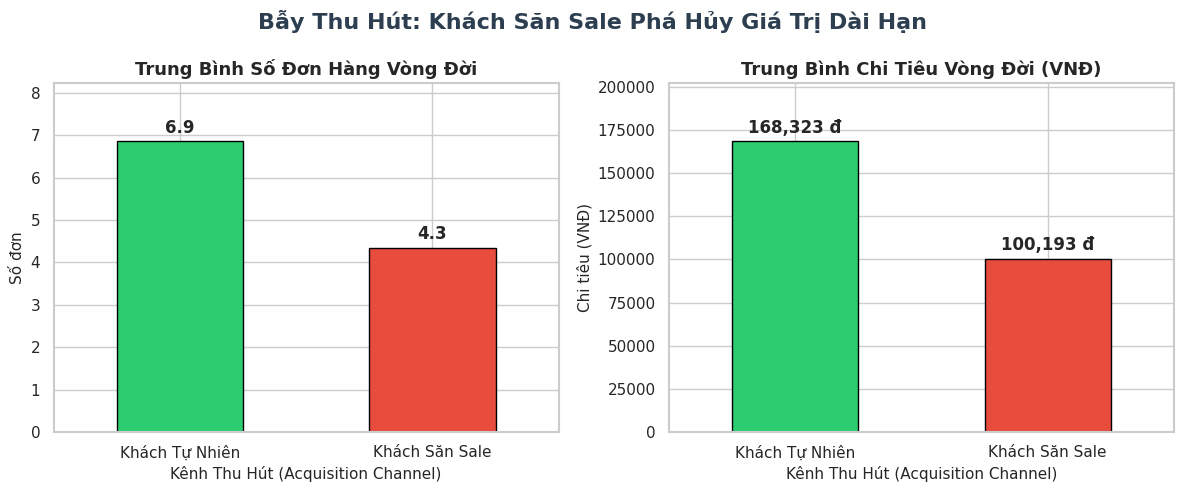

In [9]:
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']})
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#cccccc", "axes.linewidth": 1.5})

# =================================================================
# 1. LOAD DATA VÀ XỬ LÝ DỮ LIỆU
# =================================================================
orders = pd.read_csv(root_path + 'orders.csv')
items = pd.read_csv(root_path + 'order_items.csv', low_memory=False)

# Xác định đơn hàng đầu tiên và kiểm tra Promo (Chỉ tính đơn giao thành công)
orders_delivered = orders[orders['order_status'] == 'delivered']
first_orders = orders_delivered.sort_values('order_date').groupby('customer_id').first().reset_index()
promo_items = items.groupby('order_id').agg(has_promo=('promo_id', lambda x: x.notnull().any())).reset_index()
first_orders = first_orders.merge(promo_items, on='order_id', how='left')

# Tính order spend từ items để tính LTV chính xác
items['quantity'] = pd.to_numeric(items['quantity'], errors='coerce')
items['unit_price'] = pd.to_numeric(items['unit_price'], errors='coerce')
items['discount_amount'] = pd.to_numeric(items['discount_amount'], errors='coerce')
items['order_spend'] = items['unit_price'] * items['quantity'] - items['discount_amount']

order_spend = items.groupby('order_id')['order_spend'].sum().reset_index()
orders_with_spend = orders_delivered.merge(order_spend, on='order_id', how='left').fillna({'order_spend': 0})

# Tính LTV của từng khách hàng
customer_metrics = orders_with_spend.groupby('customer_id').agg(
    lifetime_orders=('order_id', 'count'),
    lifetime_spend=('order_spend', 'sum')
).reset_index()

# Gắn nhãn Acquisition Channel
final_df = first_orders.merge(customer_metrics, on='customer_id', how='left')
final_df['Acquisition_Channel'] = final_df['has_promo'].map({True: 'Khách Săn Sale', False: 'Khách Tự Nhiên'})

# Thống kê LTV theo nhóm khách hàng
ltv_stats = final_df.groupby('Acquisition_Channel').agg(
    avg_lifetime_orders=('lifetime_orders', 'mean'),
    avg_lifetime_spend=('lifetime_spend', 'mean')
).reindex(['Khách Tự Nhiên', 'Khách Săn Sale'])

# =================================================================
# 2. VẼ BIỂU ĐỒ TRỰC QUAN
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- BIỂU ĐỒ 1: SỐ ĐƠN HÀNG VÒNG ĐỜI ---
ltv_stats['avg_lifetime_orders'].plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Trung Bình Số Đơn Hàng Vòng Đời', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Số đơn', fontsize=11)
axes[0].set_xlabel('Kênh Thu Hút (Acquisition Channel)', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

# Mở rộng trần Y thêm 20% để nhãn text hiển thị thoải mái
y_max_0 = ltv_stats['avg_lifetime_orders'].max()
axes[0].set_ylim(0, y_max_0 * 1.2)

for i, v in enumerate(ltv_stats['avg_lifetime_orders']):
    axes[0].text(i, v + (y_max_0 * 0.03), f"{v:.1f}", ha='center', fontweight='bold', fontsize=12)

# --- BIỂU ĐỒ 2: CHI TIÊU VÒNG ĐỜI ---
ltv_stats['avg_lifetime_spend'].plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Trung Bình Chi Tiêu Vòng Đời (VNĐ)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Chi tiêu (VNĐ)', fontsize=11)
axes[1].set_xlabel('Kênh Thu Hút (Acquisition Channel)', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

# Mở rộng trần Y thêm 20% để nhãn text hiển thị thoải mái
y_max_1 = ltv_stats['avg_lifetime_spend'].max()
axes[1].set_ylim(0, y_max_1 * 1.2)

for i, v in enumerate(ltv_stats['avg_lifetime_spend']):
    axes[1].text(i, v + (y_max_1 * 0.03), f"{v:,.0f} đ", ha='center', fontweight='bold', fontsize=12)

# --- TỔNG THỂ ---
plt.suptitle("Bẫy Thu Hút: Khách Săn Sale Phá Hủy Giá Trị Dài Hạn", fontsize=16, fontweight='bold', color='#2c3e50')
plt.tight_layout()

plt.show()



---

## Phần 4. Đề Xuất Giải Pháp & Bài Toán Lợi Ích - Chi Phí

Dựa trên những phân tích ở 3 phần trên, nhóm xin đề xuất 5 giải pháp để giúp công ty cải thiện tình hình ngay lập tức:

### 4.1. Bài toán đánh đổi: Chấp nhận xả lỗ kho Outdoor
- **Tại sao lại chọn Outdoor:** Để làm ví dụ cho báo cáo này, nhóm chọn riêng nhóm Outdoor để chạy thử cách tính dòng tiền. Nhóm lấy tổng tồn kho tích lũy của năm 2022 là **540,081 sản phẩm** và tốc độ bán là **940 sản phẩm/tháng** để có một tập dữ liệu đủ lớn cho bài toán mô phỏng. Việc dùng số liệu mới nhất này sẽ phản ánh sát nhất tình hình ế ẩm hiện tại thay vì dùng số trung bình của các năm trước.
- **Tính toán sự đánh đổi:** Theo nhóm tìm hiểu, chi phí để duy trì kho bãi trong ngành thời trang thường rơi vào khoảng **18%/năm** (bao gồm tiền thuê kho, chi phí cơ hội, hàng bị cũ hỏng...). Nếu công ty cứ để im không làm gì (Status Quo), tiền lưu kho sẽ ăn mòn hết và Dòng tiền ròng sẽ âm tận **-0.45 Tỷ VNĐ**. Nếu công ty quyết định **Giảm giá 60% để xả lỗ**, công ty sẽ bị mất một khoản tiền do bán rẻ (vùng màu cam trên biểu đồ), nhưng bù lại hàng sẽ được tẩu tán nhanh gấp 5 lần, đỡ tốn tiền thuê kho đi rất nhiều (vùng màu đỏ xẹp xuống). Cuối cùng, Dòng tiền ròng tăng lên được **-0.32 Tỷ VNĐ**.
- **Kết luận:** Nhờ việc chấp nhận giảm giá xả hàng, công ty "đỡ lỗ" được **0.13 Tỷ VNĐ** (0.45 - 0.32). Phương pháp tính toán này có thể đem áp dụng luôn cho 2 nhóm đang tồn kho nặng nhất là Everyday và Activewear để dọn sạch kho.




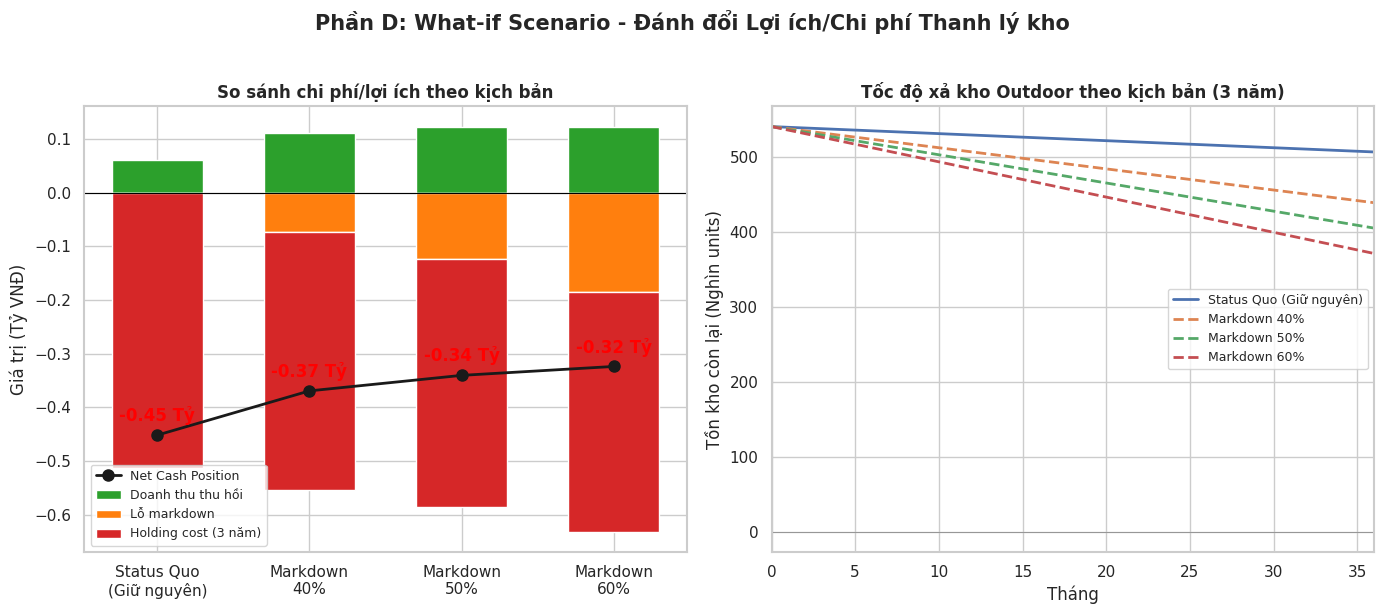

In [10]:
# CODE VẼ BIỂU ĐỒ WHAT-IF SCENARIO (DYNAMIC TỪ DỮ LIỆU)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. ĐỌC VÀ KẾT NỐI DỮ LIỆU
inv = pd.read_csv(root_path +'inventory.csv')
prods = pd.read_csv(root_path +'products.csv')

# Merge inventory với cogs (giá vốn) từ bảng products
df = inv.merge(prods[['product_id', 'cogs']], on='product_id', how='left')

# Lọc riêng nhóm Category = Outdoor và thời gian năm 2022
df_outdoor_2022 = df[(df['category'] == 'Outdoor') & (df['year'] == 2022)]

# 2. TỰ ĐỘNG TÍNH TOÁN THÔNG SỐ TỪ DỮ LIỆU
# Lấy tổng tồn kho tích lũy năm 2022 để làm quy mô giả định cho bài toán
outdoor_total_units = df_outdoor_2022['stock_on_hand'].sum()
outdoor_total_capital = (df_outdoor_2022['stock_on_hand'] * df_outdoor_2022['cogs']).sum()

# Tính trung bình số bán mỗi tháng trong năm 2022
avg_monthly_sold = df_outdoor_2022.groupby(['year', 'month'])['units_sold'].sum().mean()

# Các thông số chiến lược
holding_cost_rate = 0.18 # 18% / năm
analysis_horizon = 3 # 3 năm
avg_cogs_per_unit = outdoor_total_capital / outdoor_total_units

# 3. MÔ PHỎNG 4 KỊCH BẢN
scenarios = {
    'Status Quo\n(Giữ nguyên)': {'markdown_pct': 0.0, 'speed': 1.0},
    'Markdown\n40%': {'markdown_pct': 0.40, 'speed': 3.0},
    'Markdown\n50%': {'markdown_pct': 0.50, 'speed': 4.0},
    'Markdown\n60%': {'markdown_pct': 0.60, 'speed': 5.0},
}

results = []
for name, params in scenarios.items():
    md = params['markdown_pct']
    speed = params['speed']
    liquidation_price = avg_cogs_per_unit * (1 - md)
    monthly_sold_new = avg_monthly_sold * speed
    
    units_sold_3yr = min(monthly_sold_new * 12 * analysis_horizon, outdoor_total_units)
    units_remaining = outdoor_total_units - units_sold_3yr
    
    revenue_recovered = units_sold_3yr * liquidation_price
    markdown_loss = units_sold_3yr * avg_cogs_per_unit * md
    
    avg_inventory_value = (outdoor_total_capital + units_remaining * avg_cogs_per_unit) / 2
    holding_cost = avg_inventory_value * holding_cost_rate * analysis_horizon
    
    net_cash = revenue_recovered - holding_cost
    
    results.append({
        'Kịch bản': name,
        'Doanh thu thu hồi': revenue_recovered / 1e9,
        'Lỗ markdown': markdown_loss / 1e9,
        'Holding cost': holding_cost / 1e9,
        'Net Cash': net_cash / 1e9
    })

df_sc = pd.DataFrame(results)

# 4. VẼ BIỂU ĐỒ DUAL PANEL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(df_sc))
width = 0.6

# Biểu đồ trái
ax1.bar(x, df_sc['Doanh thu thu hồi'], width, label='Doanh thu thu hồi', color='#2ca02c')
ax1.bar(x, -df_sc['Lỗ markdown'], width, bottom=0, label='Lỗ markdown', color='#ff7f0e')
ax1.bar(x, -df_sc['Holding cost'], width, bottom=-df_sc['Lỗ markdown'], label='Holding cost (3 năm)', color='#d62728')
ax1.plot(x, df_sc['Net Cash'], 'ko-', markersize=8, linewidth=2, label='Net Cash Position')

for i, row in df_sc.iterrows():
    ax1.annotate(f"{row['Net Cash']:.2f} Tỷ", xy=(i, row['Net Cash']), xytext=(0, 10), 
                 textcoords='offset points', ha='center', fontweight='bold', 
                 color='green' if row['Net Cash'] > 0 else 'red')

ax1.set_xticks(x)
ax1.set_xticklabels(df_sc['Kịch bản'], fontsize=11)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel('Giá trị (Tỷ VNĐ)')
ax1.set_title('So sánh chi phí/lợi ích theo kịch bản', fontweight='bold')
ax1.legend(loc='lower left', fontsize=9)

# Biểu đồ phải
months = np.arange(0, 37)
for name, params in scenarios.items():
    monthly = avg_monthly_sold * params['speed']
    remaining = [max(outdoor_total_units - monthly * m, 0) for m in months]
    ax2.plot(months, [r/1000 for r in remaining], '-' if 'Status' in name else '--', linewidth=2, label=name.replace('\n', ' '))

ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('Tháng')
ax2.set_ylabel('Tồn kho còn lại (Nghìn units)')
ax2.set_title('Tốc độ xả kho Outdoor theo kịch bản (3 năm)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 36)

fig.suptitle('Phần D: What-if Scenario - Đánh đổi Lợi ích/Chi phí Thanh lý kho', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()



### 4.2. Xóa sổ lỗi "Tồn kho ảo" trên hệ thống (Khắc phục Điểm 2.1)
- **Vấn đề:** Hệ thống bị đếm sai số lượng, làm cho 30,495 lần hệ thống báo động xả lỗ bị nhầm.
- **Hành động đề xuất:** Bộ phận IT cần kiểm tra lại code đồng bộ dữ liệu. Nhóm cũng đề xuất thêm một bước cảnh báo: Nếu hệ thống báo sản phẩm vẫn còn hàng (`stock_on_hand > 0`) nhưng lại báo là hết hàng quá 15 ngày (`stockout_days > 15`), thì hệ thống phải tạm khóa lệnh tự động xả hàng của sản phẩm đó lại, đợi nhân viên kho vào kiểm tra tay rồi mới quyết định.

### 4.3. Chặn lỗi áp mã giảm giá chồng chéo (Khắc phục Điểm 2.2)
- **Vấn đề:** Khách hàng đang dùng mã khuyến mãi áp dụng lên cả những mặt hàng đang được xả lỗ (gần 99.4% đơn xả hàng bị áp mã).
- **Hành động đề xuất:** Nhóm đề xuất nên cài đặt lại hệ thống thanh toán. Nếu sản phẩm đã bị bán dưới giá vốn (đang xả hàng) thì tuyệt đối không cho phép khách hàng nhập thêm mã giảm giá nào nữa. Chỉ cần sửa lỗi nhỏ này là công ty có thể giữ lại được 600 Triệu VNĐ bị thất thoát mỗi năm.


### 4.4. Chia lại tiền nhập hàng (Khắc phục Điểm 2.3)
- **Vấn đề:** Biểu đồ phân khúc cho thấy công ty đang đổ quá nhiều tiền để nhập nhóm Everyday (nhóm bán rất chậm), trong khi nhóm Balanced bán tốt thì lại không có đủ tiền để nhập.
- **Hành động đề xuất:** Cần chia lại quỹ nhập hàng (Ngân sách OTB). Tạm thời cắt giảm một nửa (50%) ngân sách nhập hàng của nhóm Everyday và Activewear. Lấy số tiền dư ra đó đem đi nhập thêm hàng dự trữ cho nhóm Balanced để đảm bảo nhóm này không bị đứt hàng.

### 4.5. Tính toán lại lịch nhập hàng theo từng tháng (Khắc phục Điểm 3.2)
- **Vấn đề:** Công ty đang cài đặt lượng hàng nhập vào kho theo một định mức cố định quanh năm. Hậu quả là đến tháng 4 - tháng 6 (mùa khách mua nhiều nhất) thì kho lại trống rỗng không có gì để bán, còn những tháng cuối năm ế ẩm thì kho lại đầy ứ.
- **Hành động đề xuất:** Nhóm đề xuất công ty bỏ cách nhập hàng cố định. Thay vào đó, lấy "Chỉ số mùa vụ" (những tháng bán chạy) nhân thẳng vào công thức nhập hàng. Cụ thể: Trước khi vào Mùa Vàng (Tháng 4 - 6), kho phải tự động tăng mức hàng dự phòng lên mức tối đa. Ngược lại, vào các tháng thấp điểm thì chủ động giảm lượng nhập xuống. Thay đổi nhỏ này sẽ giúp công ty hốt trọn doanh thu lúc khách đông và không bị chôn vốn ôm hàng vào cuối năm.

